# Digital Earth Australia Fractional Cover
This notebook demonstrates how to use DEA's Fractional Cover dataset

The notebook demonstrates:

1. How to load fractional cover scenes
1. How to apply mask fractional cover scenes using DEA Water Observations
1. How to load fractional cover annual percentile product

## Set up
The following cell should be uncommented and run if you installed the package in editable mode and are actively developing and testing modules.
Otherwise, it can be left commented.

In [1]:
# %load_ext autoreload
# %autoreload 2

### Enable logging

This will allow you to see info and warning messages from the package.

In [2]:
import logging
import sys

logging.basicConfig(
    format="%(asctime)s | %(levelname)s : %(message)s",
    level=logging.INFO,
    stream=sys.stdout,
)

### Import the relevant packages


In [3]:
import numpy as np
from pprint import pprint

from eo_insights.stac_configuration import de_australia_stac_config
from eo_insights.raster_base import RasterBase, QueryParams, LoadParams
from eo_insights.masking import generate_bit_mask

## Set up and run query

For more information on how to load data, see [load_demo.ipynb](load_demo.ipynb).

Load fractional cover scenes.

In [ ]:
query_params = QueryParams(
    bbox=(143.05, -37.95, 143.15, -37.85),
    start_date="2023-11-01",
    end_date="2023-11-30",
    # Optional (not implemented in query yet): pass additional filters for cloud or platform landsat 7 can be excluded
)

load_params_fc = LoadParams(
    crs="EPSG:3577",
    resolution=30,
    bands=("bs", "pv", "npv"),
)

stac_raster_fc = RasterBase.from_stac_query(
    config=de_australia_stac_config,
    collections=["ga_ls_fc_3"],
    query_params=query_params,
    load_params=load_params_fc,
)

2025-08-25 20:55:24,794 | WARNING : There were no configured masks found for ga_ls_fc_3
2025-08-25 20:55:24,795 | INFO : No masks were found for the requested collections


/Users/fang/miniforge3/envs/eoinsights/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


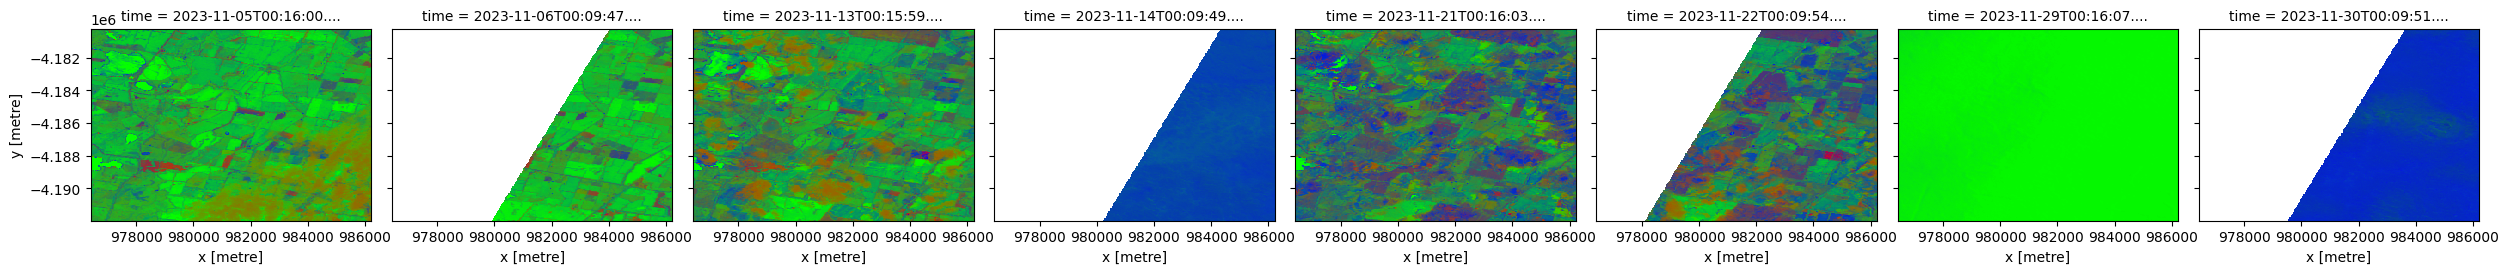

In [5]:
# Display first three scenes
stac_raster_fc.data[
    ["bs", "pv", "npv"]
].to_array().plot.imshow(col="time", vmin=0, vmax=100)

### Retrieve Water Observation scenes for masking

In [ ]:
load_params_wo = LoadParams(
    crs="EPSG:3577",
    resolution=30,
    bands=("water"),
    # TODO: use a spectial fuse_func for wo
)

stac_raster_wo = RasterBase.from_stac_query(
    config=de_australia_stac_config,
    collections=["ga_ls_wo_3"],
    query_params=query_params,
    load_params=load_params_wo,
)

In [7]:
dry_mask = generate_bit_mask(stac_raster_wo.masks.water, {"dry": True}, stac_raster_wo.masks.water.attrs['flags_definition'])

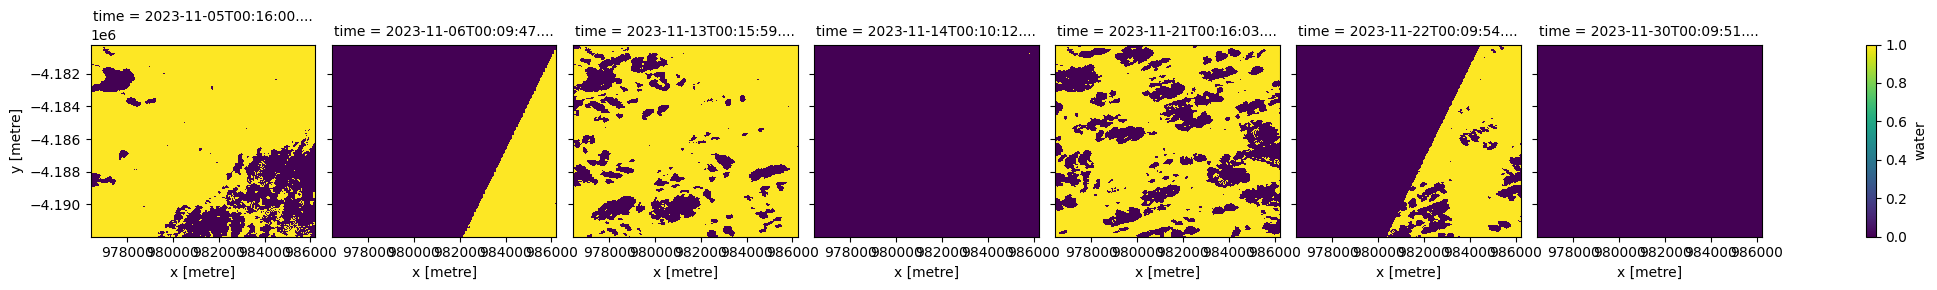

In [8]:
dry_mask.plot.imshow(col="time")

In [9]:
filtered_fc = stac_raster_fc.data.where(dry_mask)

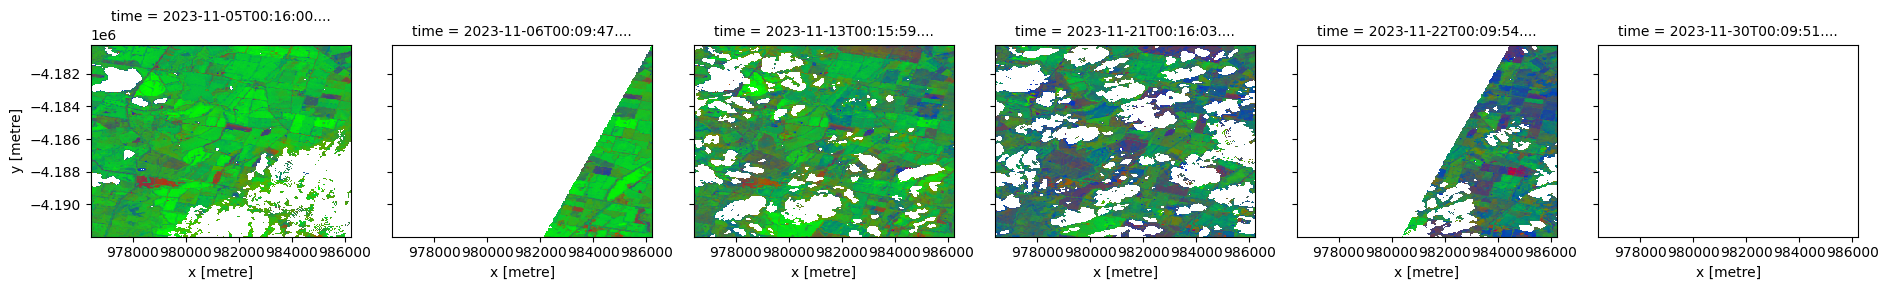

In [10]:
filtered_fc[
    ["bs", "pv", "npv"]
].to_array().plot.imshow(col="time", vmin=0, vmax=100)

## Query for Fractional Cover Percentiles

This product is available as an annual product.

In [11]:
query_params = QueryParams(
    bbox=(143.05, -37.95, 143.15, -37.85),
    start_date="2023-01-01",
    end_date="2023-12-31",
)

load_params_fc_pc = LoadParams(
    crs="EPSG:3577",
    resolution=30,
    bands=("bs_pc_10", "bs_pc_50", "bs_pc_90", "pv_pc_10", "pv_pc_50", "pv_pc_90", "npv_pc_10", "npv_pc_50", "npv_pc_90", "qa"),
)

stac_raster_fc_pc = RasterBase.from_stac_query(
    config=de_australia_stac_config,
    collections=["ga_ls_fc_pc_cyear_3"],
    query_params=query_params,
    load_params=load_params_fc_pc,
)

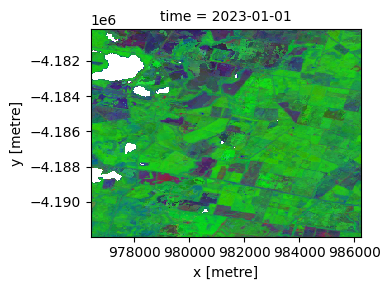

In [12]:
stac_raster_fc_pc.data[
    ["bs_pc_50", "pv_pc_50", "npv_pc_50"]
].to_array().plot.imshow(col="time", vmin=0, vmax=100)

In [13]:
stac_raster_fc_pc.apply_mask("qa", data_inplace=False, mask_inplace=False)

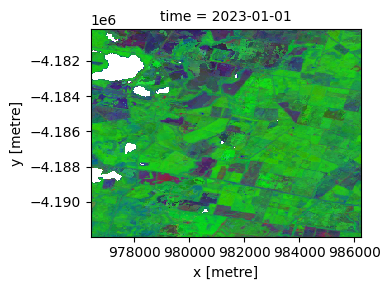

In [14]:
stac_raster_fc_pc.data[
    ["bs_pc_50_masked", "pv_pc_50_masked", "npv_pc_50_masked"]
].to_array().plot.imshow(col="time", vmin=0, vmax=100)